### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [29]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn import metrics
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep="\t", header=0, engine="python", quoting=0)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

У нас пропущені дані тільки в колонці Income. Проаналізуємо середнє та медіану за рівнем освіти.

In [4]:
df.groupby("Education")["Income"].mean().sort_values(ascending=False)

Education
PhD           56145.313929
Master        52917.534247
Graduation    52720.373656
2n Cycle      47633.190000
Basic         20306.259259
Name: Income, dtype: float64

In [5]:
stats = df.groupby("Education")["Income"].agg([
    "mean",
    "std",
    "count",
    "median",
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
])

stats.columns = ["mean", "std", "count", "median", "q25", "q75"]

print(stats)

                    mean           std  count   median       q25       q75
Education                                                                 
2n Cycle    47633.190000  22119.081838    200  46805.0  27526.50  65393.25
Basic       20306.259259   6235.066773     54  20744.0  15405.25  24882.00
Graduation  52720.373656  28177.192681   1116  52028.5  34834.50  69930.50
Master      52917.534247  20157.788029    365  50943.0  37760.00  66726.00
PhD         56145.313929  20612.979997    481  55212.0  40451.00  69098.00


<Axes: title={'center': 'Income'}, xlabel='Education'>

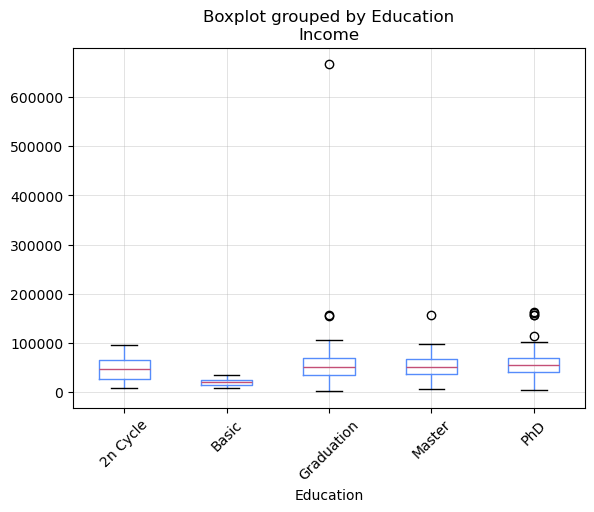

In [6]:
df.boxplot(column="Income", by="Education", rot=45)

Є викиди по рівнях Graduation, Master, PhD - тому краще заповнити медіаною в залежності від рівня освіти та сімейного стану.

In [7]:
df["Income"] = df["Income"].fillna(
    df.groupby(["Education", "Marital_Status"])["Income"].transform("median")
)

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

Для категоріальних колонок (Education, Marital_Status) використаємо One-Hot Encoding

In [8]:
df = pd.get_dummies(df, columns=["Education", "Marital_Status"], drop_first=True)

Для колонки Dt_Customer: порахуємо скільки часув клієнт з нами, додатково додамо колнки customer_year, customer_month

In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

In [10]:
df["customer_days"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

In [11]:
df["customer_year"] = df["Dt_Customer"].dt.year
df["customer_month"] = df["Dt_Customer"].dt.month

Видаляємо оригінальну дату

In [12]:
df = df.drop(columns=["Dt_Customer"])

Додамо ще 2 фічі по загальних витратах та покупках клієнтів

In [13]:
df["total_spent"] = (
    df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] +
    df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
)

df["total_purchases"] = (
    df["NumWebPurchases"] + df["NumCatalogPurchases"] + df["NumStorePurchases"]
)

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

Видалимо непотрібні колонки

In [14]:
X = df.drop(columns=["ID", "Response"], errors="ignore")

Будуємо кластеризацію KMeans

In [15]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)
labels = kmeans.predict(X)
df["cluster"] = labels

Обчислимо метрику силуету

In [16]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.60


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [17]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="Income",
    y="total_spent",
    z="total_purchases",
    color="cluster",
    opacity=0.7
)

fig.write_html("clusters.html")
# fig.show()

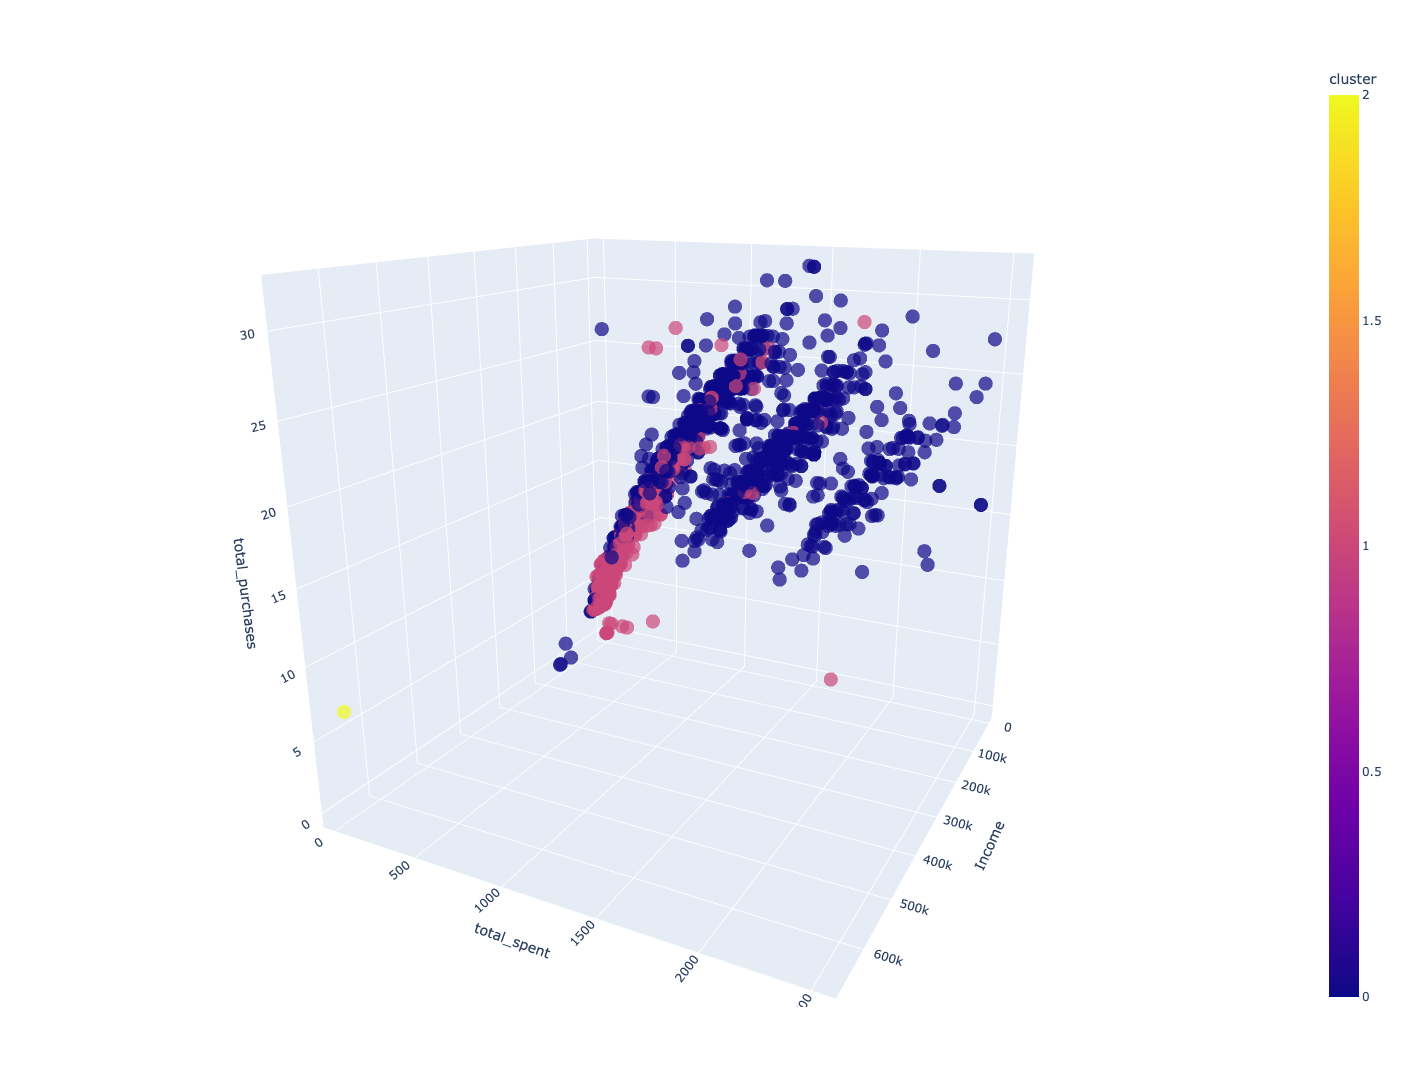
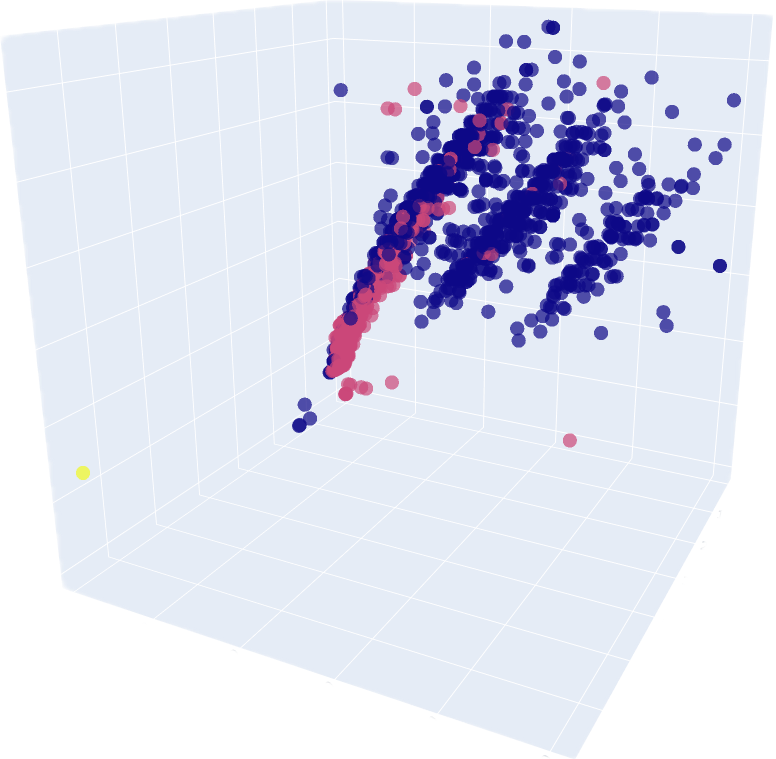

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X_scaled)
labels = kmeans.predict(X_scaled)
df["cluster"] = labels

In [20]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X_scaled, labels, metric='euclidean')
print(f'Silhouette Coefficient for the scaled data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the scaled data Dataset Clusters: 0.13


Після масштабування значення silhouette coefficient зменшилось до 0.13. Різниця значна, можливо Income мали великі значення, що впливає на кластеризацію. Після масштабування всі фічі стали рівними, зявився шум від менш корисних фіч.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [21]:
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()

    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean

Будемо опрацьовувати не всі колонки, а лише ті що мають значення

In [22]:
cols = ["Income", "total_spent", "total_purchases"]

df_clean = remove_outliers_iqr(df, cols)

Подивимось на розмір датасету до та після видалення викидів

In [23]:
print(len(df), "→", len(df_clean))

2240 → 2229


**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

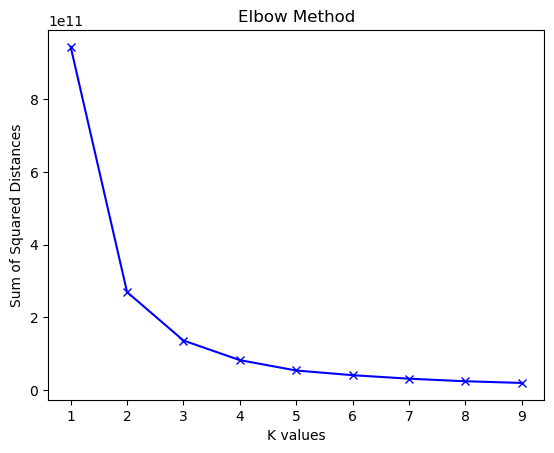

In [24]:
X = df_clean.drop(columns=["ID", "Response"], errors="ignore")

K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [25]:
for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, n_init='auto')
    labels = kmeans.fit_predict(X)
    print(k, metrics.silhouette_score(X, labels, metric='euclidean'))

2 0.6045875020831448
3 0.5502028033551819
4 0.5308960070421569
5 0.5358906342808942


In [81]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)
labels = kmeans.predict(X)

In [82]:
X["cluster"] = labels

fig = px.scatter_3d(
    X,
    x="Income",
    y="total_spent",
    z="total_purchases",
    color="cluster",
    opacity=0.7
)

fig.write_html("clusters_2.html")

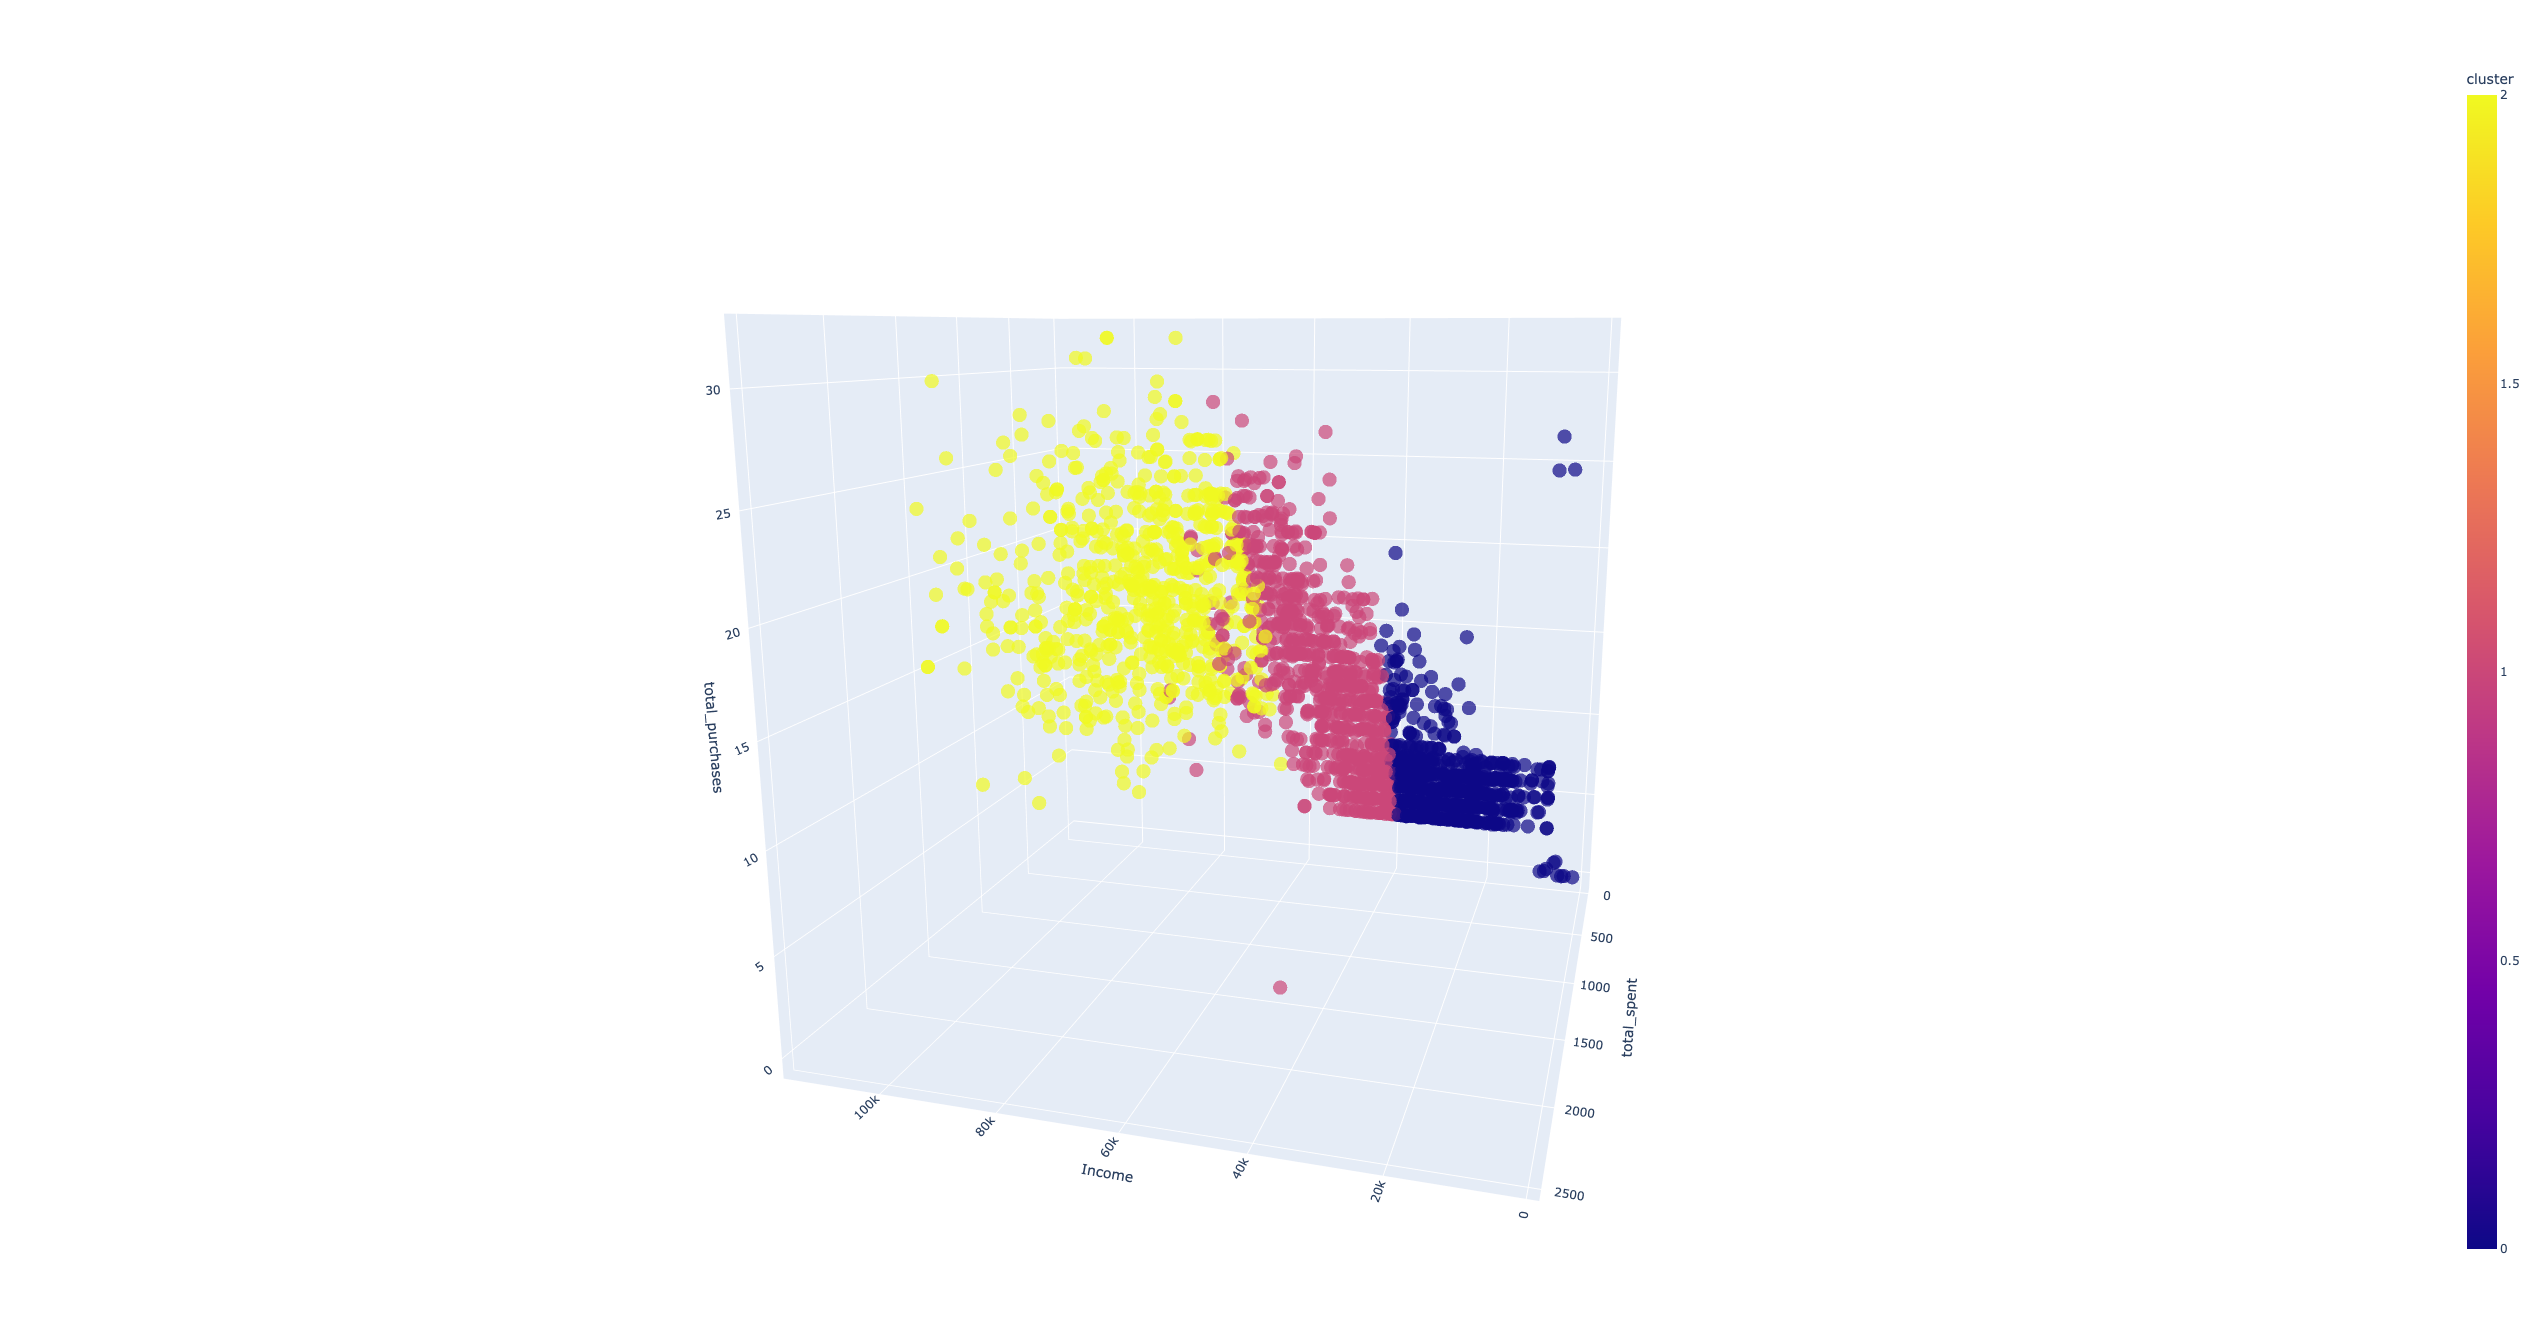
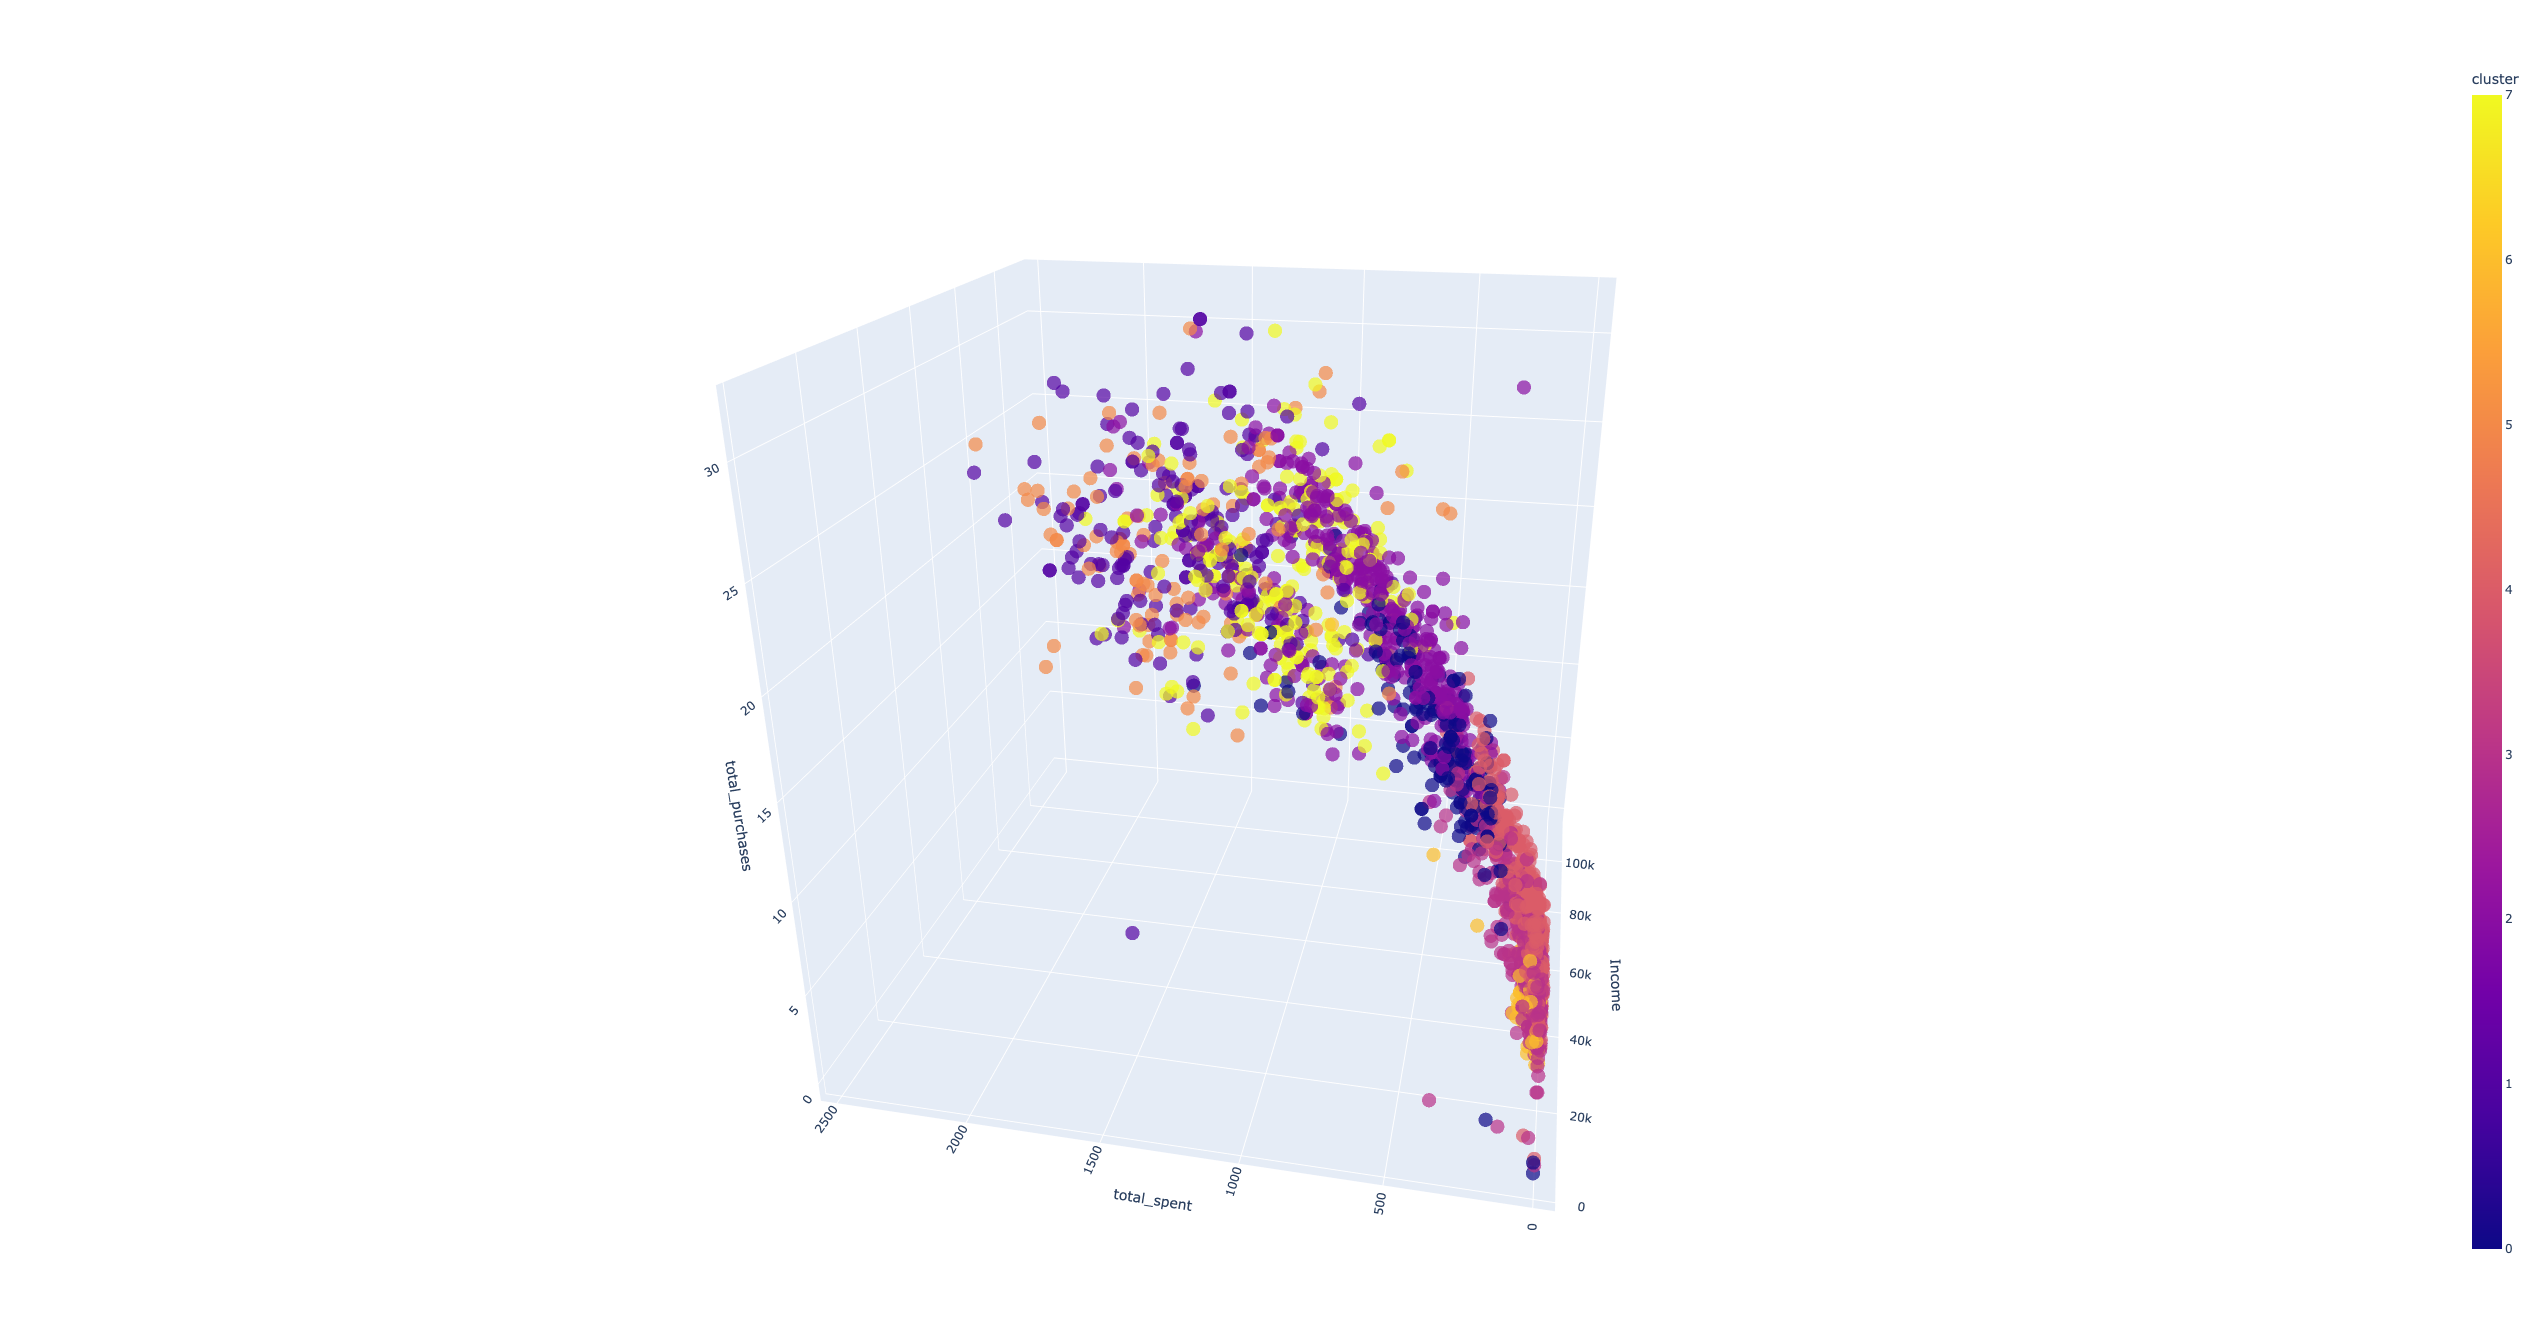
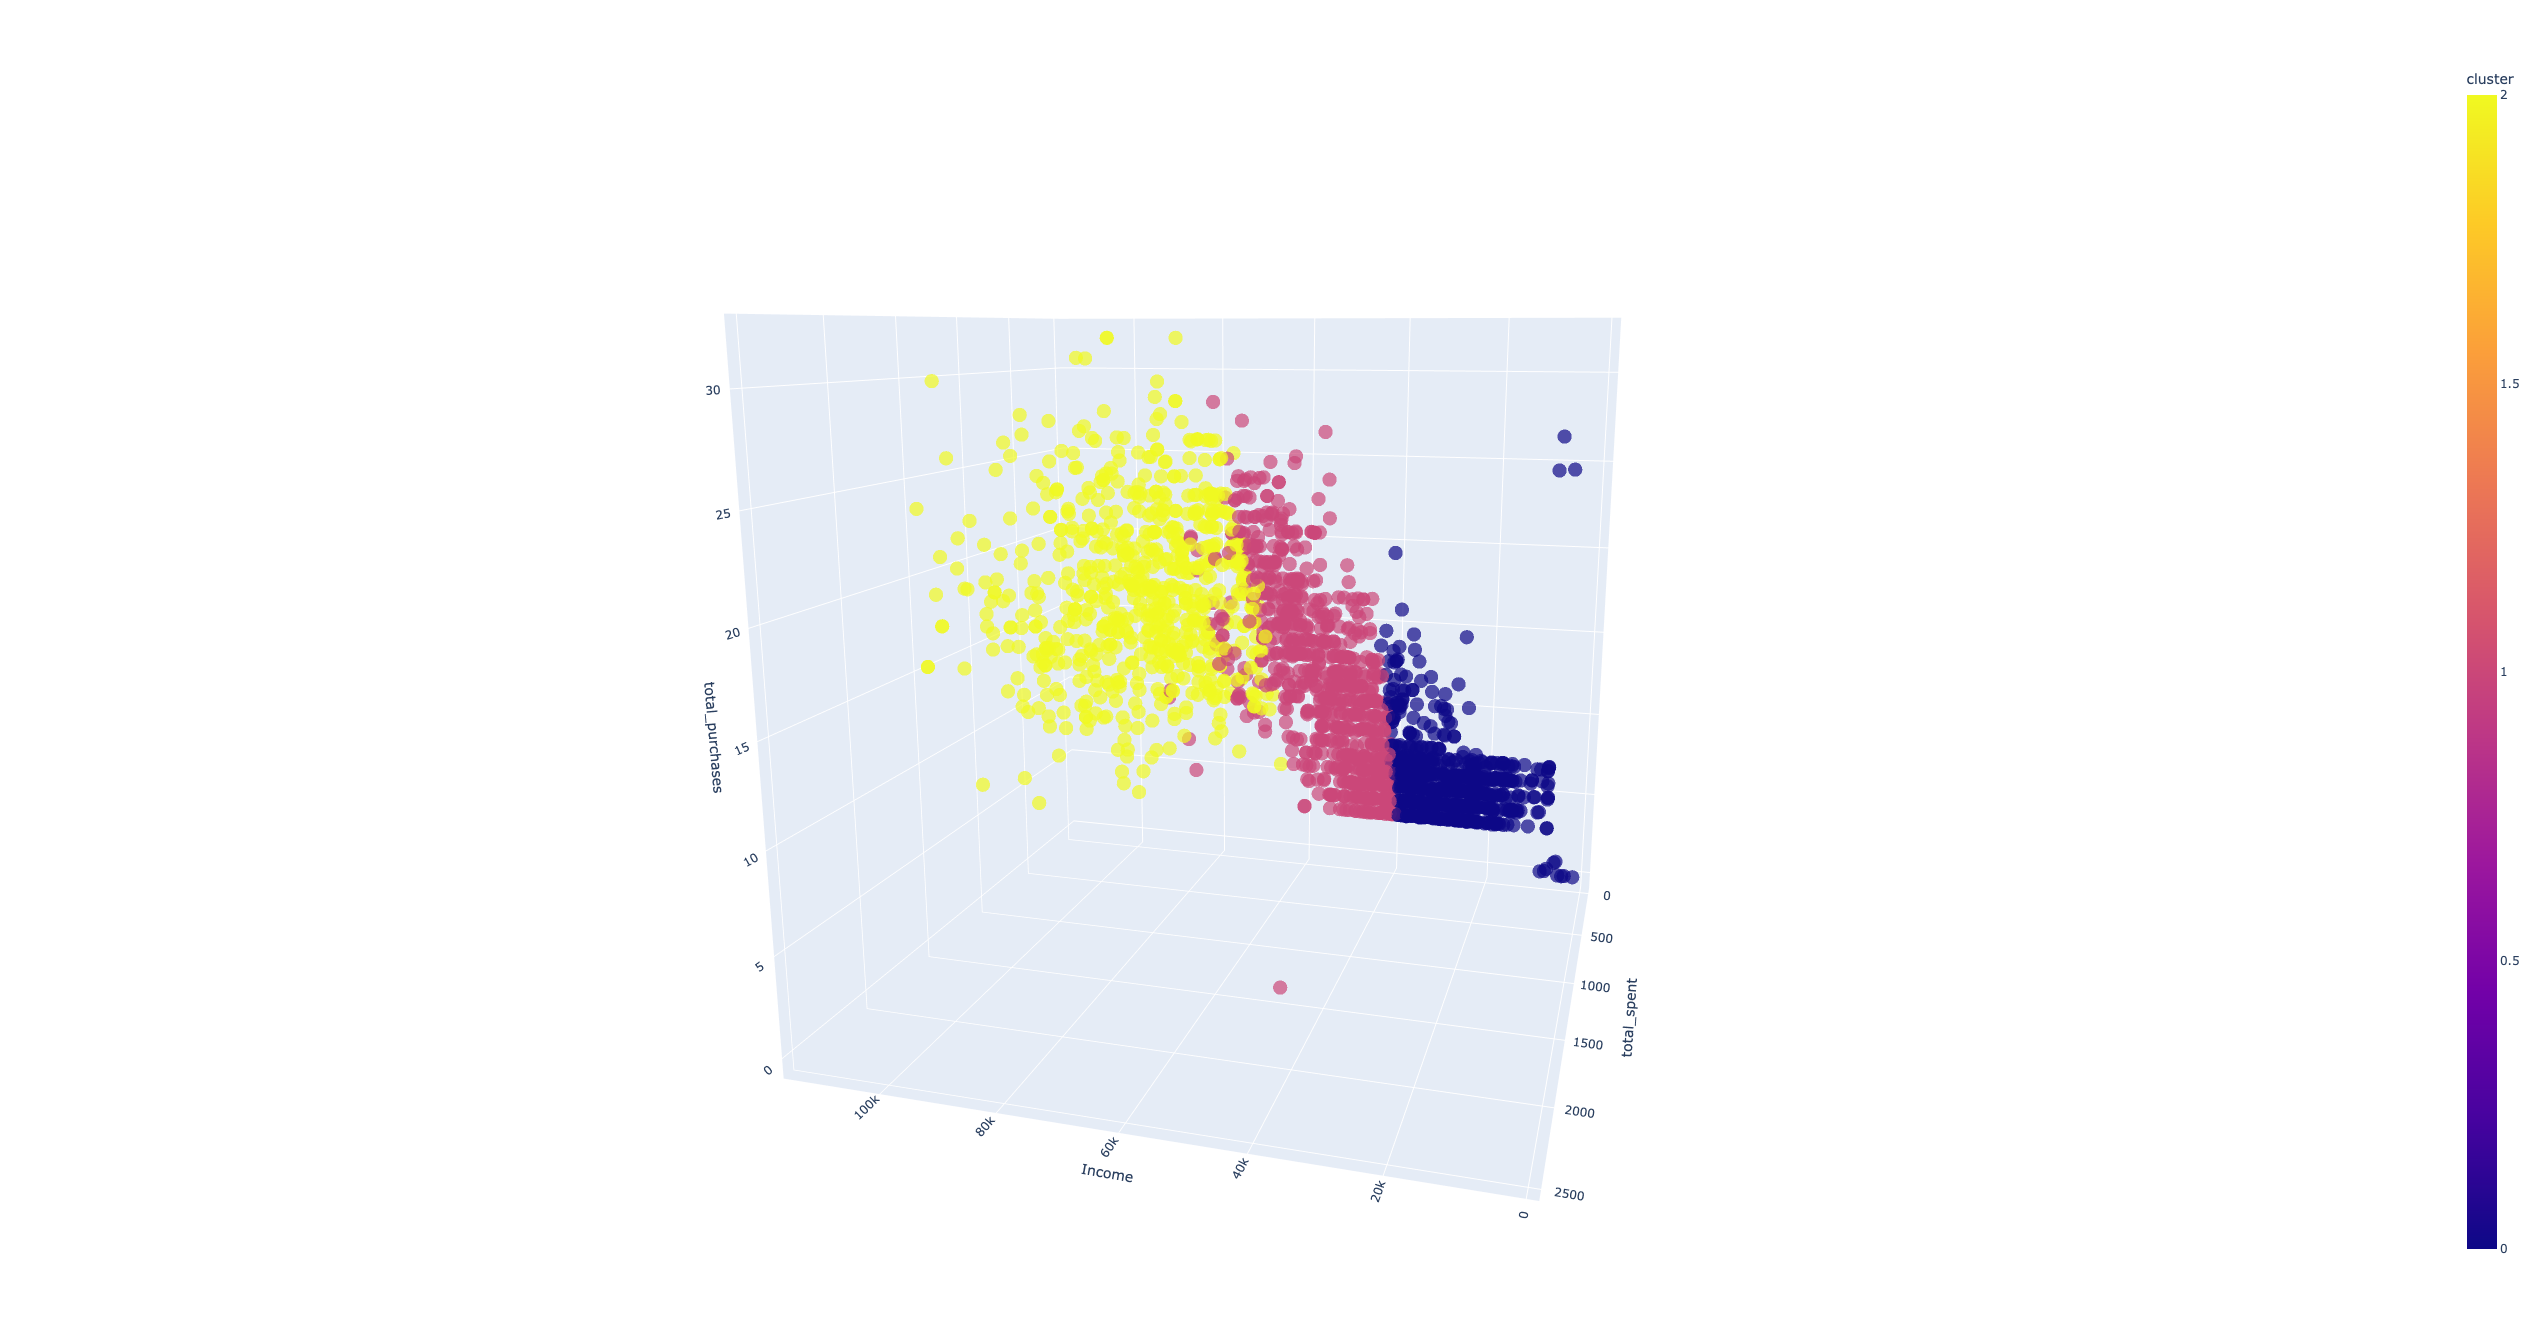
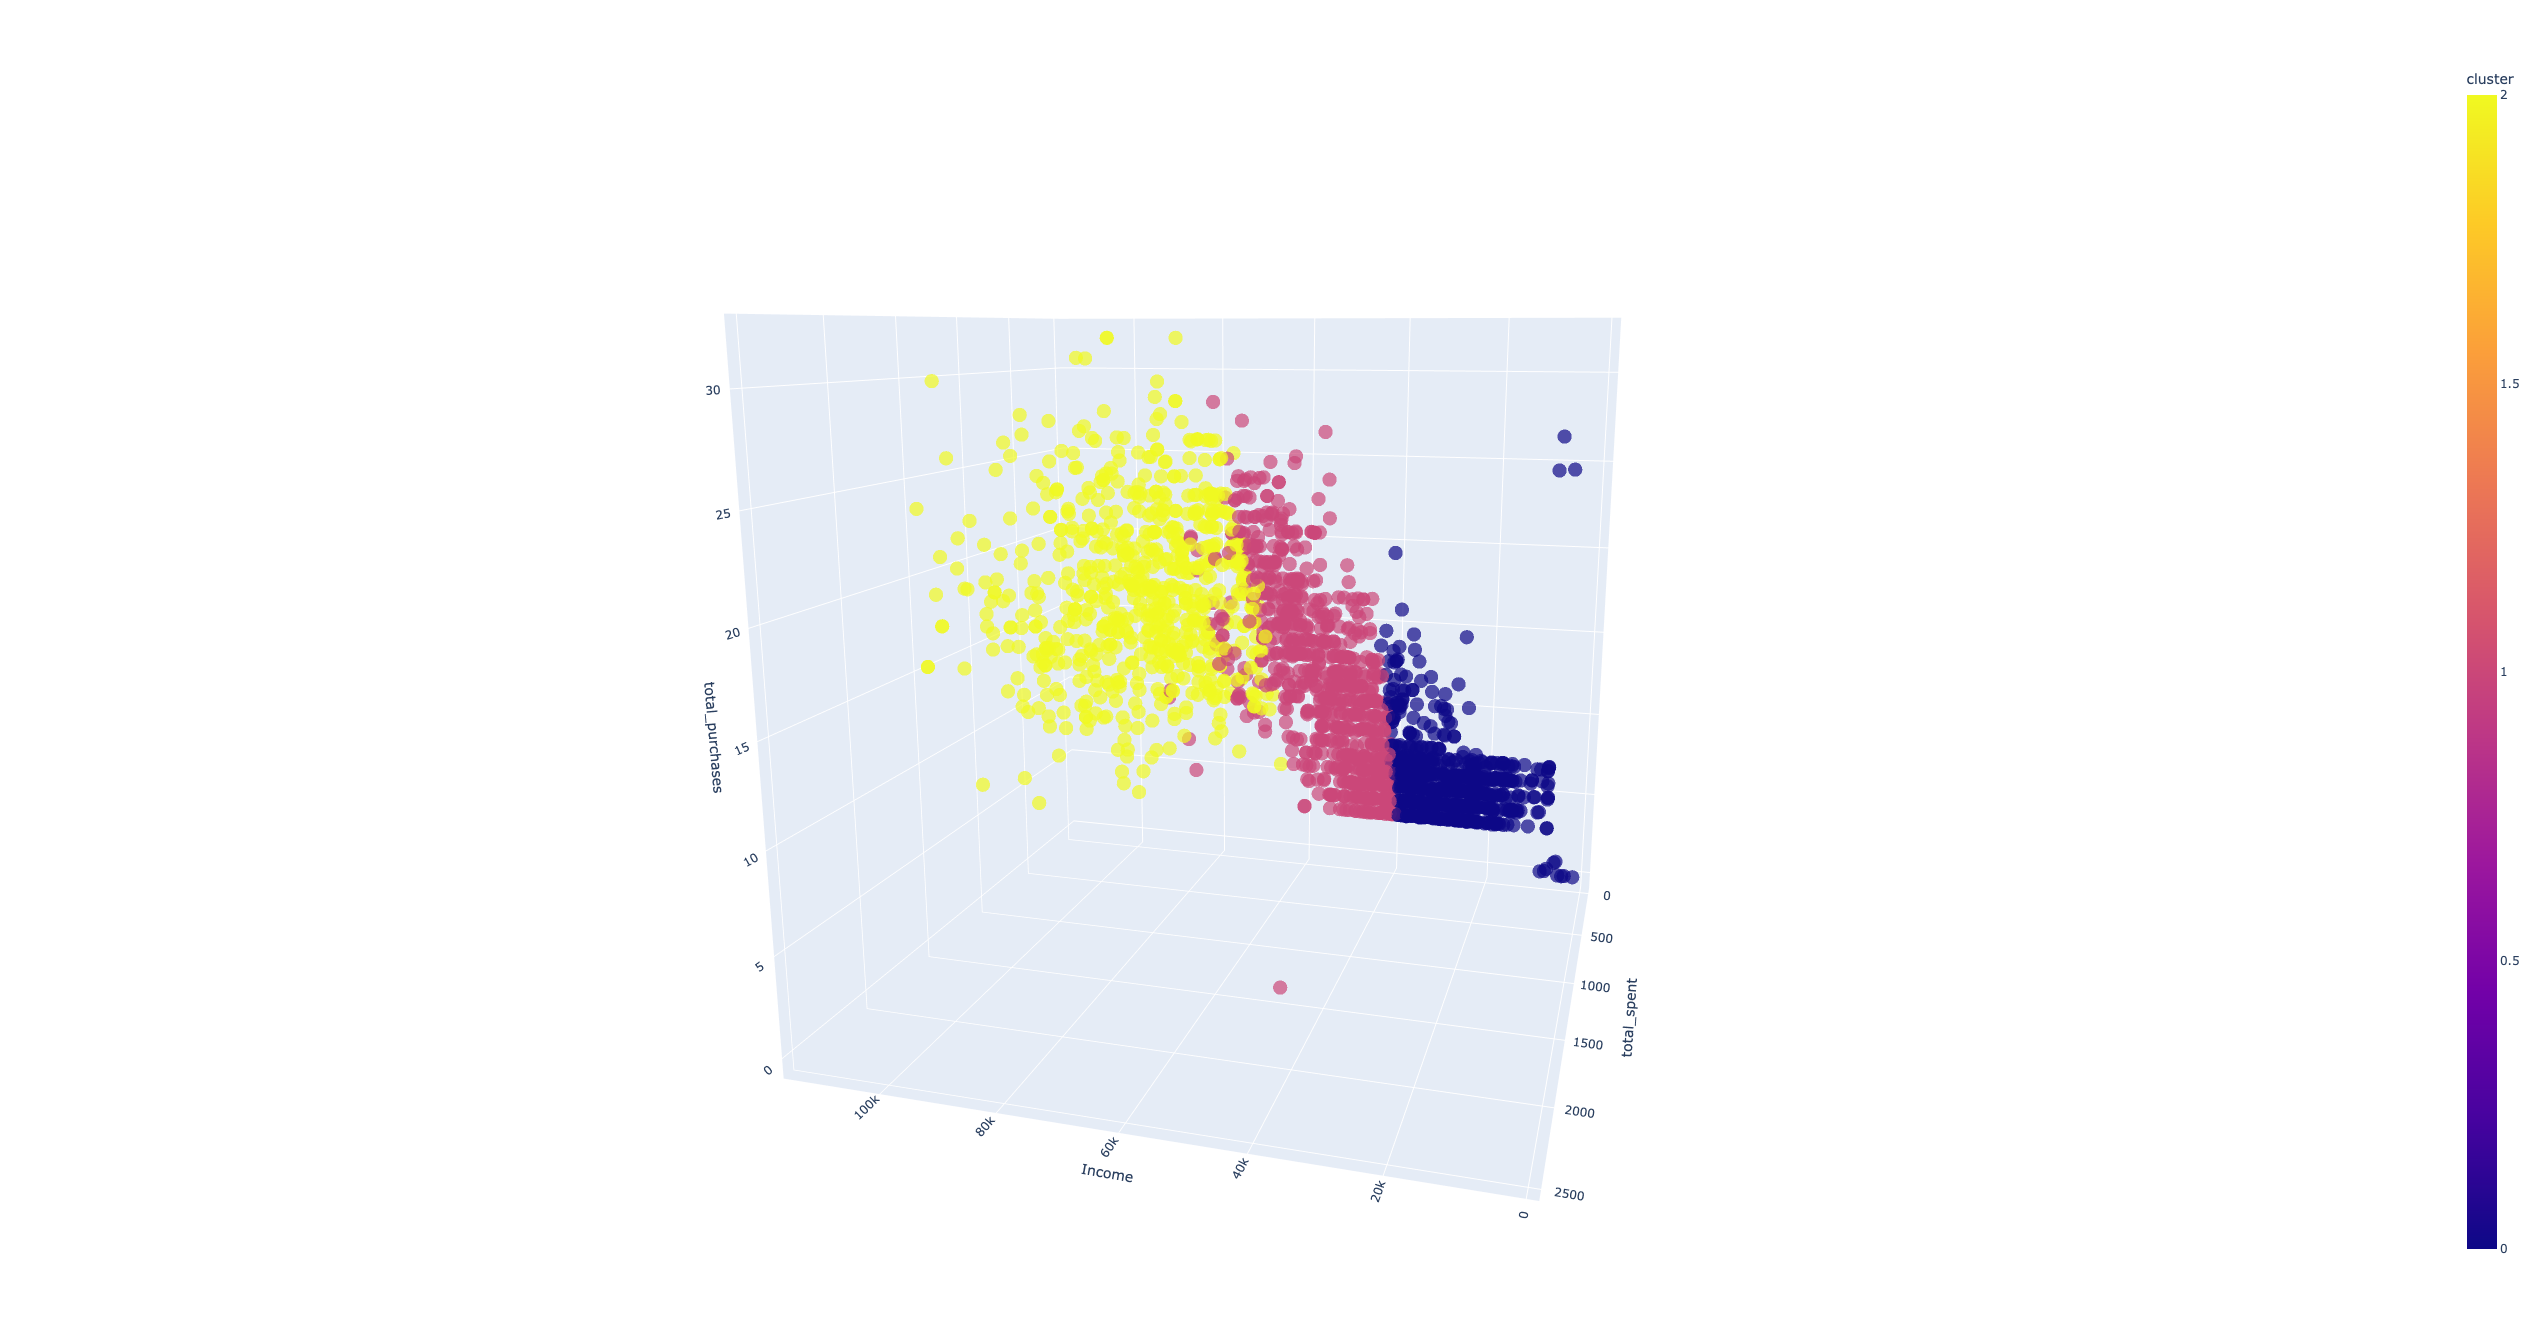
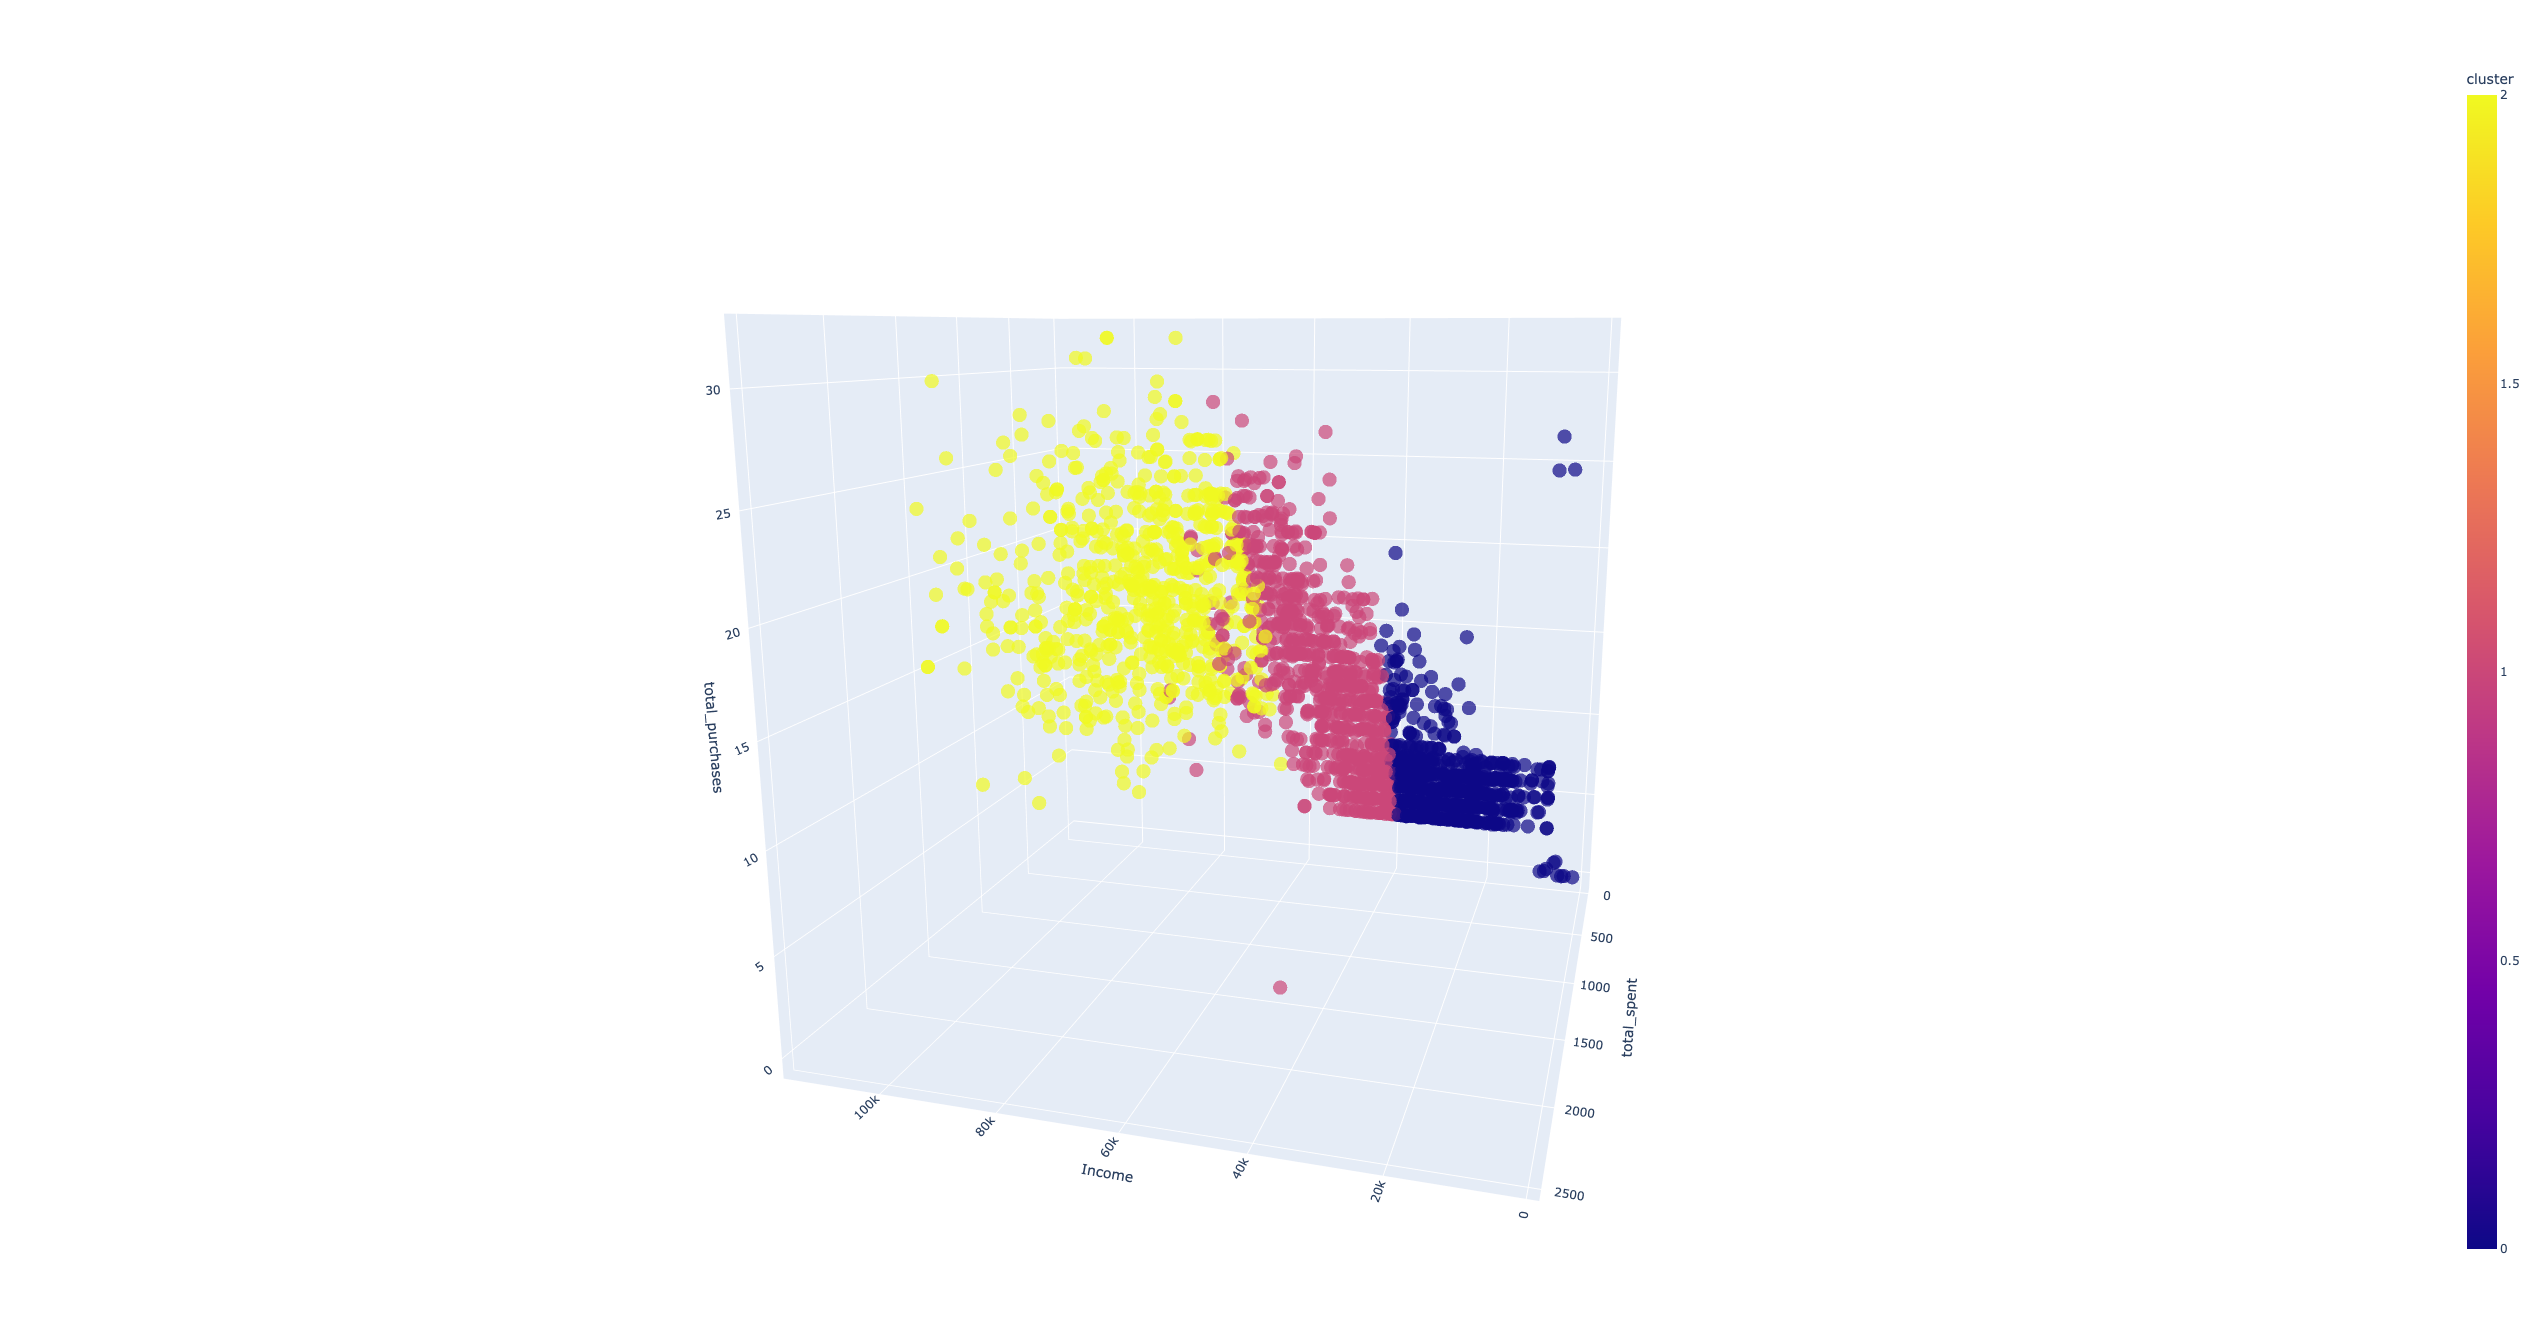

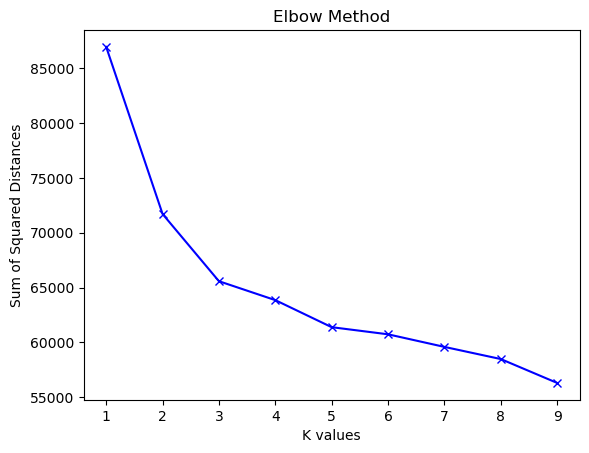

In [26]:
X_scaled = scaler.fit_transform(X)

K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X_scaled)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [27]:
for k in [2, 3, 4, 5, 6]:
    kmeans = KMeans(n_clusters=k, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    print(k, metrics.silhouette_score(X_scaled, labels, metric='euclidean'))

2 0.19905302827381302
3 0.15493321388397538
4 0.07917364102926282
5 0.09065124184904466
6 0.07065207765317727


In [28]:
kmeans = KMeans(n_clusters=5, n_init='auto')
kmeans.fit(X_scaled)
labels = kmeans.predict(X_scaled)

In [85]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df["cluster"] = labels

fig = px.scatter_3d(
    X_scaled_df,
    x="Income",
    y="total_spent",
    z="total_purchases",
    color="cluster",
    opacity=0.7
)

fig.write_html("clusters_3.html")

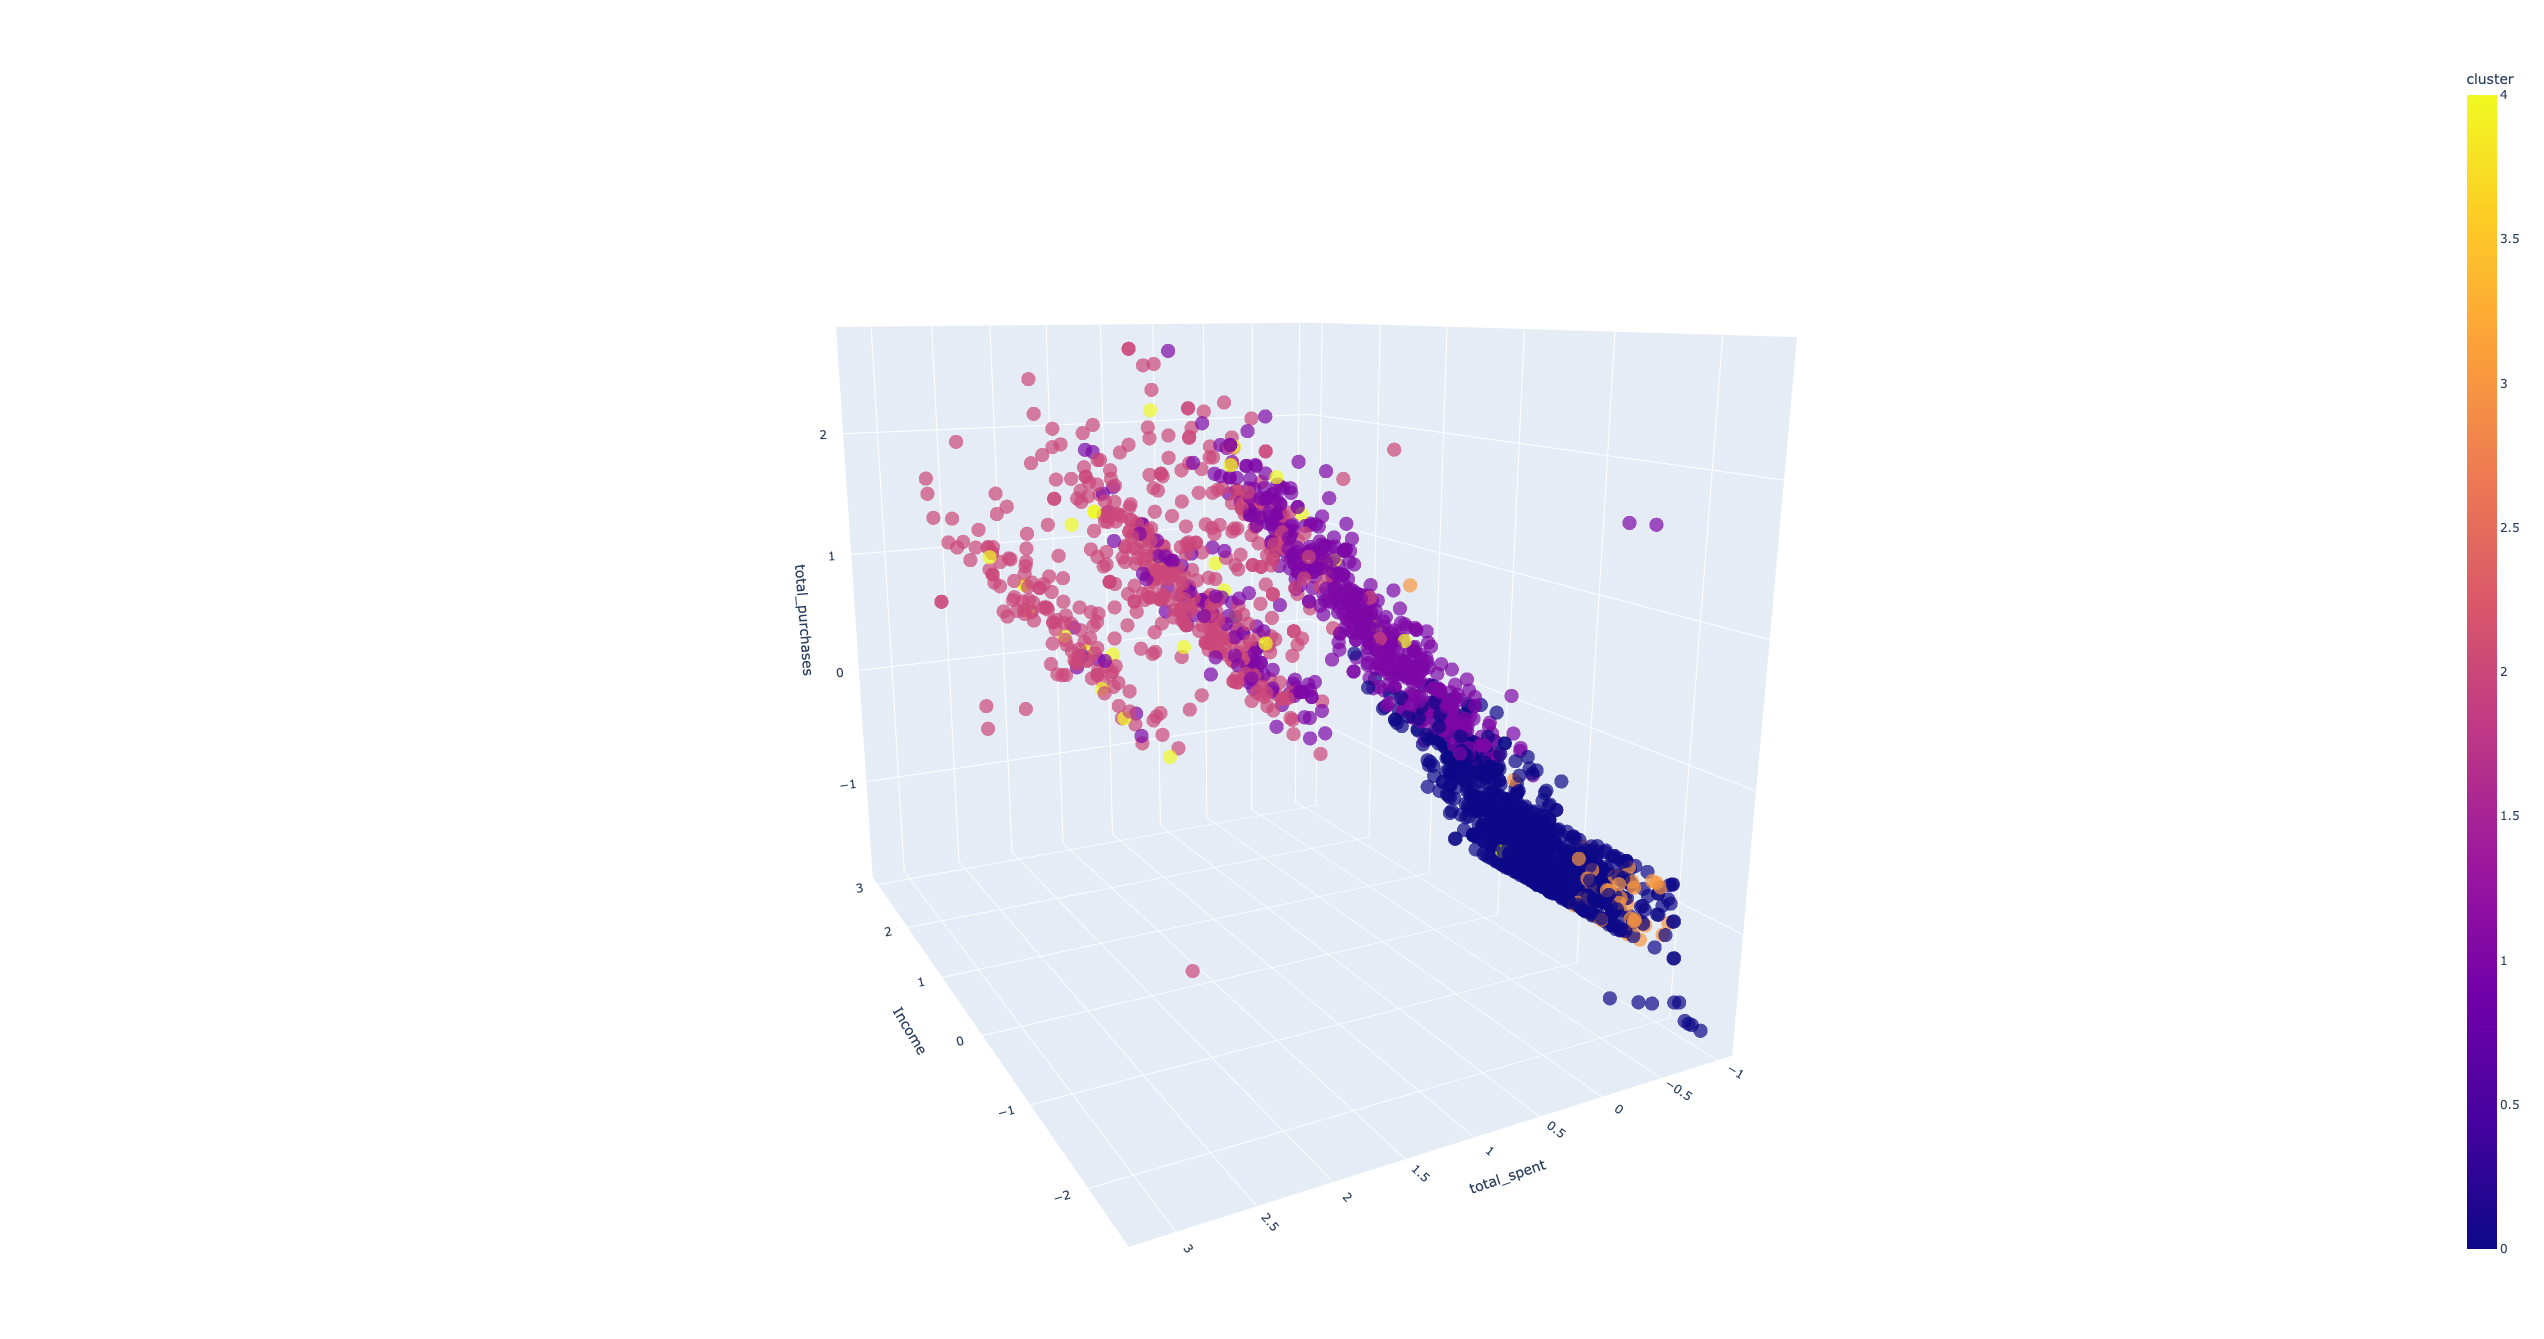

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

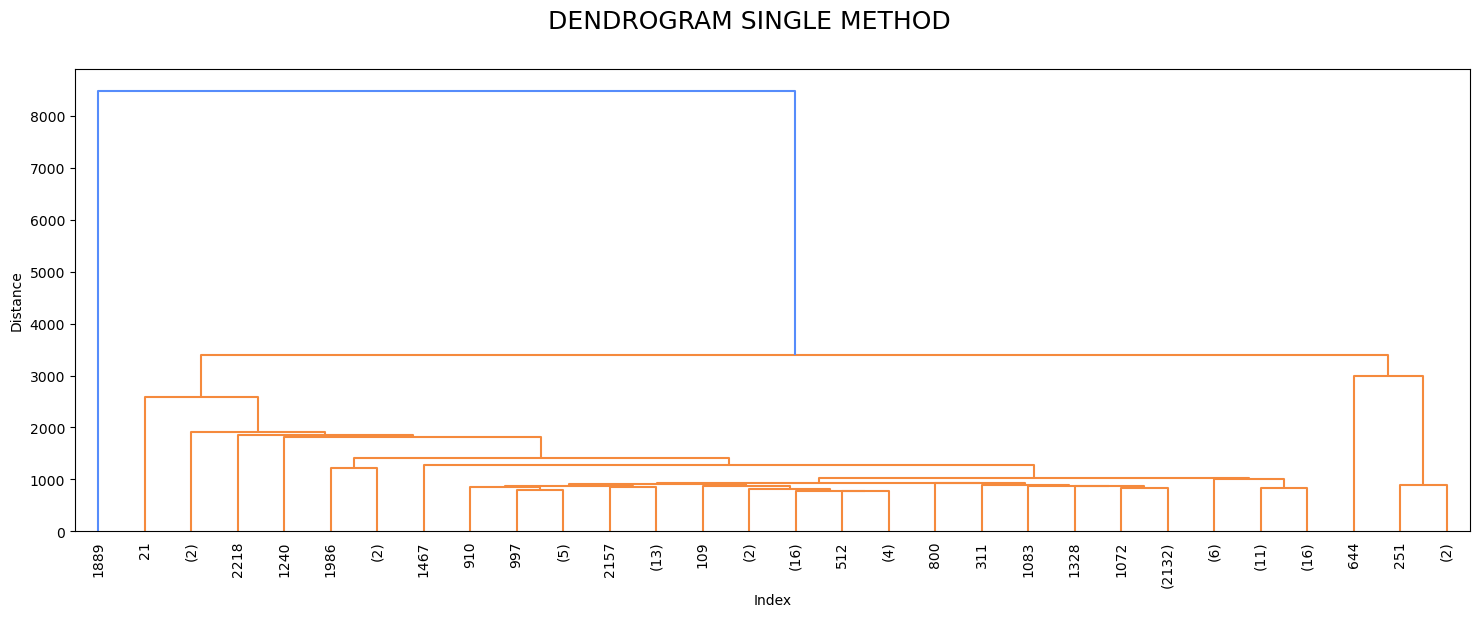

In [42]:
dist_sin = linkage(X, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, truncate_mode='lastp', leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [45]:
labels_2 = fcluster(dist_sin, 2, criterion="maxclust")

labels_3 = fcluster(dist_sin, 3, criterion="maxclust")

In [48]:
df_vis = df_clean.copy()
df_vis["2_clust"] = labels_2
df_vis["3_clust"] = labels_3

In [49]:
df_vis.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Marital_Status_Widow,Marital_Status_YOLO,customer_days,customer_year,customer_month,total_spent,total_purchases,cluster,2_clust,3_clust
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,False,False,4978,2012,9,1617,22,2,1,1
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,False,False,4428,2014,3,27,4,1,1,1
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,False,False,4627,2013,8,776,20,0,1,1
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,False,False,4454,2014,2,53,6,1,1,1
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,False,False,4476,2014,1,422,14,1,1,1


<Axes: title={'center': 'Ground Truth'}, xlabel='Income', ylabel='total_spent'>

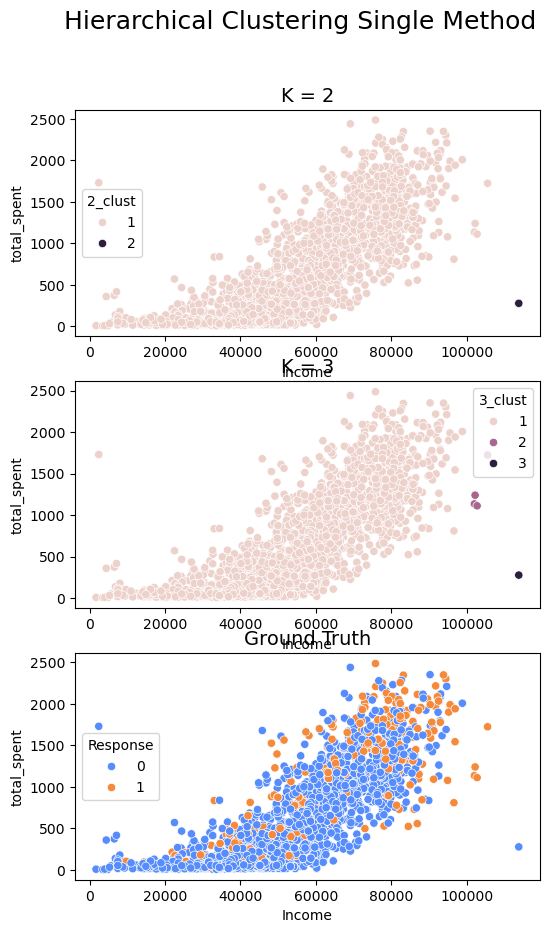

In [50]:
import seaborn as sns

plt.figure(figsize=(6,10))

plt.suptitle("Hierarchical Clustering Single Method",fontsize=18)

plt.subplot(3,1,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="Income",y="total_spent", data=df_vis, hue="2_clust")

plt.subplot(3,1,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="Income",y="total_spent", data=df_vis, hue="3_clust")

plt.subplot(3,1,3)
plt.title("Ground Truth",fontsize=14)
sns.scatterplot(x="Income",y="total_spent", data=df_vis, hue="Response")

In [47]:
from sklearn.metrics import silhouette_score

sil_2 = silhouette_score(X, labels_2)
sil_3 = silhouette_score(X, labels_3)

print("Silhouette score for single linkage, 2 clusters:", sil_2)
print("Silhouette score for single linkage, 3 clusters:", sil_3)

Silhouette score for single linkage, 2 clusters: 0.5585334080793309
Silhouette score for single linkage, 3 clusters: 0.45189988385736507


Hierarchical Clustering Single Method - не демонструє можливості виділити компактні та добре відокремлені кластери.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

Спробуємо застосувати DBSCAN

In [75]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)

labels = dbscan.fit_predict(X_scaled)

In [76]:
df_clean_dbs = df_clean.copy()
df_clean_dbs["cluster_dbscan"] = labels

In [77]:
from sklearn.metrics import silhouette_score
import numpy as np

if len(set(labels)) > 1 and -1 not in set(labels):
    score = silhouette_score(X_scaled, labels)
    print("Silhouette:", score)
else:
    print("Silhouette не рахується (1 кластер або є шум)")

Silhouette не рахується (1 кластер або є шум)


In [78]:
df_clean_dbs

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,customer_days,customer_year,customer_month,total_spent,total_purchases,cluster,cluster_dbscan
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,False,False,False,4978,2012,9,1617,22,2,-1
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,False,False,False,4428,2014,3,27,4,1,-1
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,True,False,False,4627,2013,8,776,20,0,-1
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,True,False,False,4454,2014,2,53,6,1,-1
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,False,False,False,4476,2014,1,422,14,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,61223.0,0,1,46,709,43,182,42,...,False,False,False,4696,2013,6,1341,16,0,-1
2236,4001,1946,64014.0,2,1,56,406,0,30,0,...,True,False,False,4334,2014,6,444,15,0,-1
2237,7270,1981,56981.0,0,0,91,908,48,217,32,...,False,False,False,4470,2014,1,1241,18,2,-1
2238,8235,1956,69245.0,0,1,8,428,30,214,80,...,True,False,False,4471,2014,1,843,21,0,-1


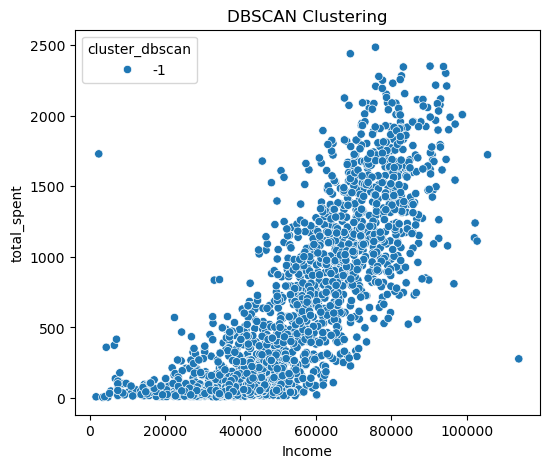

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.scatterplot(
    x="Income",
    y="total_spent",
    data=df_clean_dbs,
    hue="cluster_dbscan",
    palette="tab10"
)

plt.title("DBSCAN Clustering")
plt.show()

DBSCAN - це алгоритм, який може виявляти кластери будь-якої форми, але він може бути нестабільним і не завжди дає гарні результати. В даному випадку, алгоритм DBSCAN виявив 1 кластер, тобто більшість об’єктів формують один великий кластер, а частина точок класифікується як шум. Дана кластеризація не є дуже корисною для сегментації, але добре демонструє, що структура даних скоріше є безперервною, ніж кластерною.